# A6: Seattle coffee shop visualizations

Same data pipeline as **`week5/A5analysis.ipynb`** (Seattle open data → coffee-related trade names → `zip_counts` and `openings`).

**Static images:** these charts use **matplotlib**, so each figure is saved with `fig.savefig(...)` to `week6/figures/` as **PNG** (no extra engine). For **Plotly** charts, use `fig.write_image("file.png")` instead — that path needs **`kaleido`** installed (see the setup cell in **`week6_mp1_starter.ipynb`**).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def _a6_figure_dir() -> Path:
    """Resolve week6/figures whether the kernel cwd is repo root or week6."""
    cwd = Path.cwd().resolve()
    if (cwd / "A6.ipynb").is_file():
        return cwd / "figures"
    if (cwd / "week6" / "A6.ipynb").is_file():
        return cwd / "week6" / "figures"
    return cwd / "figures"


FIG_DIR = _a6_figure_dir()
FIG_DIR.mkdir(parents=True, exist_ok=True)

URL = "https://data.seattle.gov/resource/wnbq-64tb.json?$limit=50000"
df = pd.read_json(URL)

coffee_kw = r"coffee|cafe|espresso"
coffee_mask = df["trade_name"].str.contains(coffee_kw, case=False, na=False)
coffee = df.loc[coffee_mask].copy()

seattle_mask = coffee["city"].fillna("").str.upper().eq("SEATTLE")
coffee_sea = coffee.loc[seattle_mask].copy()


def clean_zip5(z):
    if pd.isna(z):
        return pd.NA
    s = str(z).split("-", 1)[0].strip()
    s = s[:5]
    return s if len(s) == 5 and s.isdigit() else pd.NA


coffee_sea["zip5"] = coffee_sea["zip"].map(clean_zip5)
coffee_sea["license_start"] = pd.to_datetime(
    coffee_sea["license_start_date"], format="%Y%m%d", errors="coerce"
)
coffee_sea["open_year"] = coffee_sea["license_start"].dt.year

zip_counts = (
    coffee_sea.dropna(subset=["zip5"])
    .groupby("zip5", as_index=False)
    .size()
    .rename(columns={"size": "coffee_shop_licenses"})
    .sort_values("coffee_shop_licenses", ascending=False)
)

openings = (
    coffee_sea.loc[coffee_sea["open_year"].between(2000, 2024)]
    .groupby("open_year")
    .size()
    .rename("new_openings")
    .sort_index()
)

Matplotlib is building the font cache; this may take a moment.


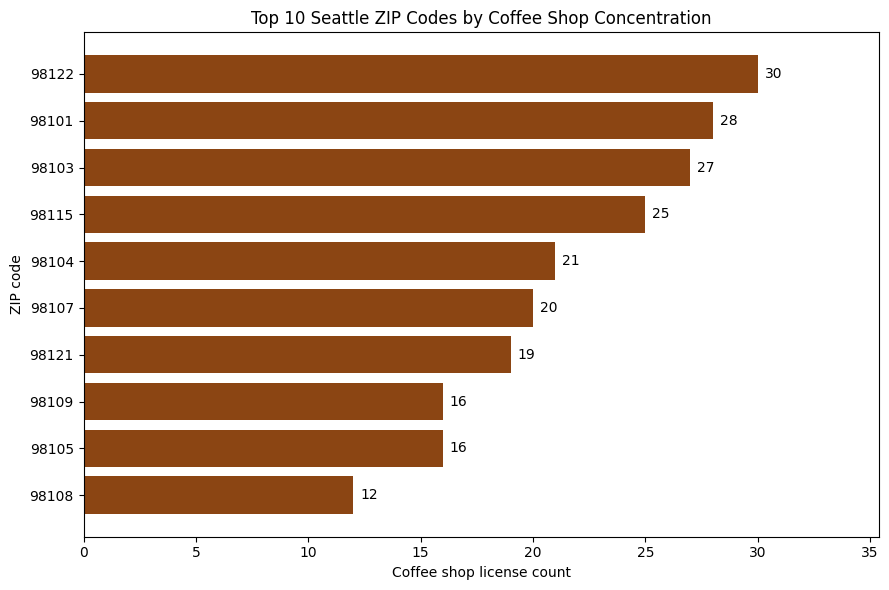

In [2]:
# 1) Horizontal bar chart — top 10 Seattle ZIPs by coffee shop license count
top10 = zip_counts.head(10).sort_values("coffee_shop_licenses", ascending=True)
zips = top10["zip5"].astype(str)
counts = top10["coffee_shop_licenses"].values

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(zips, counts, color="saddlebrown")
ax.set_xlabel("Coffee shop license count")
ax.set_ylabel("ZIP code")
ax.set_title("Top 10 Seattle ZIP Codes by Coffee Shop Concentration")

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + max(counts) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(w)}",
        va="center",
        ha="left",
        fontsize=10,
    )

ax.set_xlim(0, max(counts) * 1.18)
fig.tight_layout()
fig.savefig(FIG_DIR / "a6_top10_seattle_zip_coffee.png", dpi=200, bbox_inches="tight")
plt.show()

ZIP code 98122 (Capitol Hill) has the highest concentration of coffee shop licenses in Seattle with 30, narrowly beating downtown 98101 with 28 and Fremont/Wallingford 98103 with 27. This was surprising because downtown Seattle has significantly more foot traffic, but Capitol Hill's dense residential neighborhood and strong local culture appears to support more independent coffee businesses.

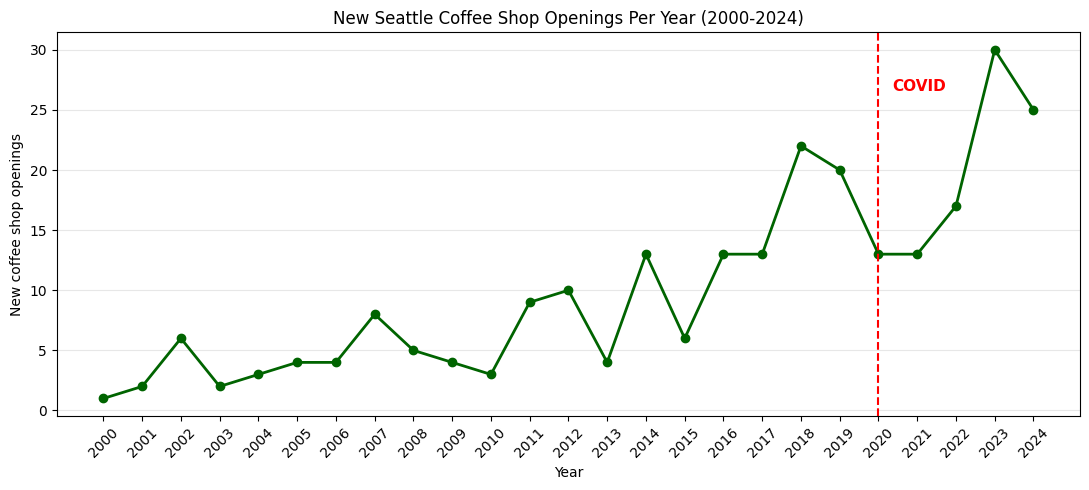

In [3]:
# 2) Line chart — new openings per year (2000–2024), COVID marker at 2020
years = list(range(2000, 2025))
yvals = openings.reindex(years, fill_value=0).astype(int)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(years, yvals, marker="o", color="darkgreen", linewidth=2, markersize=6)
ax.axvline(2020, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Year")
ax.set_ylabel("New coffee shop openings")
ax.set_title("New Seattle Coffee Shop Openings Per Year (2000-2024)")
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)

ymax = float(yvals.max())
ax.text(
    2020.35,
    ymax * 0.92,
    "COVID",
    color="red",
    fontsize=11,
    fontweight="bold",
    va="top",
)

ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "a6_openings_per_year.png", dpi=200, bbox_inches="tight")
plt.show()

New coffee shop openings in Seattle were low and steady through the 2000s, peaked at 22 in 2018, then dropped to 13 in 2020 likely due to the COVID pandemic discouraging new business registrations. Openings rebounded strongly and hit a record high of 30 in 2023, suggesting Seattle's coffee scene is growing faster than ever post-pandemic.